### Bibliotecas

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import osmnx as ox
import networkx as nx
from itertools import combinations
import multiprocessing as mp

print(f'Utilizando a versão {ox.__version__} do OSMNX')

print(f'Eu tenho {mp.cpu_count()} CPUs disponíveis')

Utilizando a versão 2.0.1 do OSMNX
Eu tenho 8 CPUs disponíveis


P### Parâmetros

In [4]:
#caminho = '/Users/marcelofernandes/Library/CloudStorage/GoogleDrive-marcelo.fernandes@alumni.usp.br/.shortcut-targets-by-id/1M--OnzbTYagrNv5Ss9fjWlBxCMmasz-Y/10_Mestrado_2021_Marcelo Fernandes/6_Qualificação/Mapas temáticos e figuras/BACIA_HIDROGRAFICA/SIRGAS_BACIAHIDROGRAFICA.shp'
caminho = '/Users/marcelofernandes/Library/CloudStorage/GoogleDrive-marcelo.fernandes@alumni.usp.br/My Drive/Mapas temáticos e figuras/BACIA_HIDROGRAFICA/SIRGAS_BACIAHIDROGRAFICA.shp'

my_crs = '4326'  # Verificar em EPSG.io um projeção que te dê o resultado em metros

pesquisa_OD = '/Users/marcelofernandes/Library/CloudStorage/GoogleDrive-marcelo.fernandes@alumni.usp.br/.shortcut-targets-by-id/1M--OnzbTYagrNv5Ss9fjWlBxCMmasz-Y/10_Mestrado_2021_Marcelo Fernandes/8_Dados/Pesquisa OD 2017/OD-2017/Mapas-OD2017/Shape-OD2017/Zonas_2017_region.shp'
plt.style.use('ggplot')

arquivo_matrizOD = '/Users/marcelofernandes/Library/CloudStorage/GoogleDrive-marcelo.fernandes@alumni.usp.br/.shortcut-targets-by-id/1M--OnzbTYagrNv5Ss9fjWlBxCMmasz-Y/10_Mestrado_2021_Marcelo Fernandes/4_Códigos/Dados/OD-2017/Tabelas-OD2017/Tab25_OD2017.xlsx'

verbose = False  # Flag para pular algumas atividades, com o objetivo de economizar memória.

ox.settings.log_console = True
ox.settings.use_cache = True    

### Carregar bacias

O sistema de coordendadas utilizado é o EPSG:4326


<Axes: >

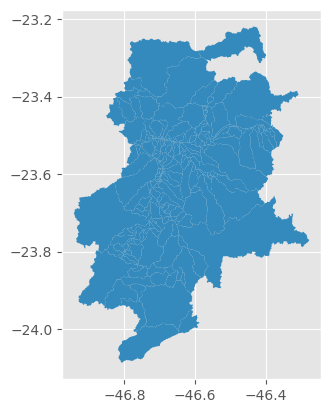

In [5]:
### Carregar e selecionar as bacias hidrográficas
# Informações relevantes sobre os sistemas de coordenadas do GeoSampa
# Nota técnica: No GeoSampa são fornecidos arquivos tanto na projeção SAD69(96) como SIRGAS2000 e WGS84. 
# A projeção em SAD69(96) é fornecida apenas em caráter de compatibilidade com bases antigas, visto que, em 2014,
# foi definida a projeção UTM/SIRGAS2000 (EPGS: 31983) como a nova referência para o Sistema Geodésico Brasileiro (SGB)
# e para o Sistema Cartográfico Nacional (SCN). Desde então são consideradas oficiais apenas as informações
# produzidas tendo o Sirgas2000 como sistema geodésico.

# Read the shapefile
gdf_bacia = gpd.read_file(caminho)

# Atribuição do esquema de projeção
gdf_bacia = gdf_bacia.set_crs(epsg=31983)
gdf_bacia = gdf_bacia.to_crs(my_crs)

# Verifica o sistema de coordenadas
print(f'O sistema de coordendadas utilizado é o {gdf_bacia.crs}')

# Plotar o geodataframe
gdf_bacia.plot()

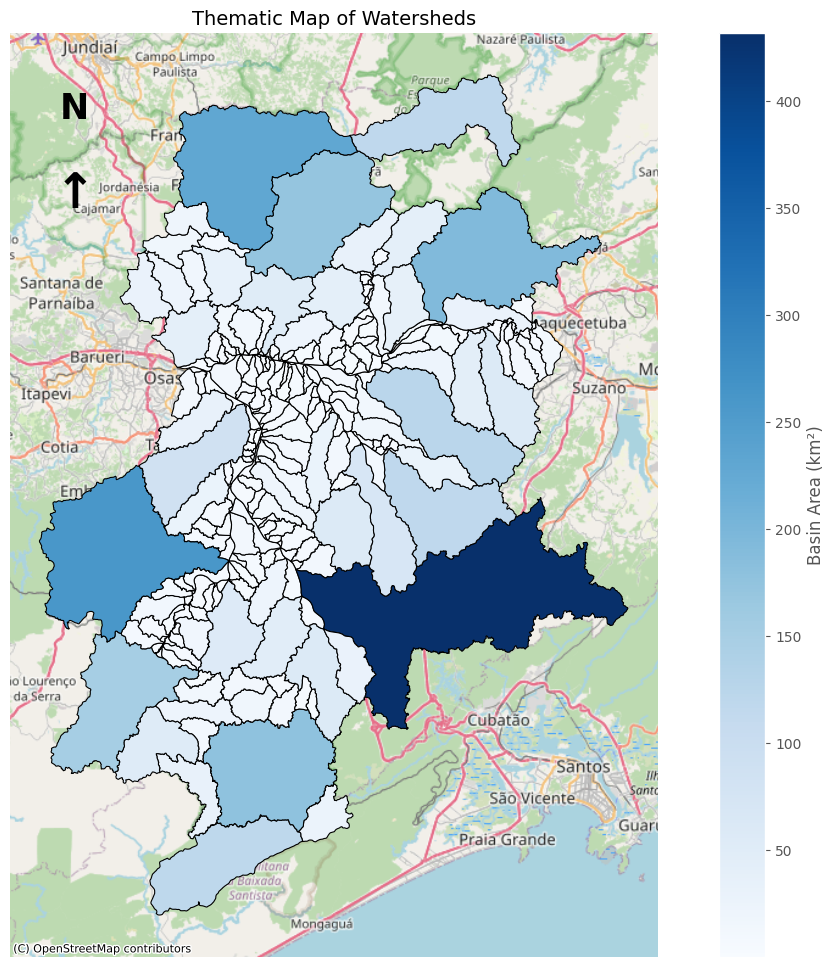

In [29]:
import contextily as ctx  # To add a base map

# Ensure the CRS is set and transform to EPSG:3857 for contextily
if gdf_bacia.crs is None:
    gdf_bacia = gdf_bacia.set_crs(epsg=31983)  # Set to SIRGAS2000 if CRS is missing

# Convert to EPSG:3857 (Web Mercator) for basemap compatibility
gdf_bacia = gdf_bacia.to_crs(epsg=3857)

# Create a thematic variable (example: coloring by basin area)
gdf_bacia["area_km2"] = gdf_bacia.geometry.area / 10**6  # Converting to km²

# Create the thematic map
fig, ax = plt.subplots(figsize=(16, 12))
gdf_bacia.plot(column="area_km2", cmap="Blues", linewidth=0.8, edgecolor="black", 
               legend=True, legend_kwds={"label": "Basin Area (km²)", "orientation": "vertical"}, ax=ax)

# Add a title
ax.set_title("Thematic Map of Watersheds", fontsize=14)

# Add a background map (optional)
ctx.add_basemap(ax, crs=gdf_bacia.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Remove axes
ax.set_axis_off()

# Function to add a north arrow
def add_north_arrow(ax, x=0.1, y=0.9, size=0.1, text="N"):
    ax.annotate(text, xy=(x, y), xycoords='axes fraction', fontsize=25, fontweight='bold',
                ha='center', va='bottom', rotation=0)
    ax.annotate("↑", xy=(x, y - size), xycoords='axes fraction', fontsize=35, fontweight='bold',
                ha='center', va='bottom')

# Add North Arrow
add_north_arrow(ax)

# Display the map
plt.show()


AttributeError: 'NoneType' object has no attribute 'to_string'

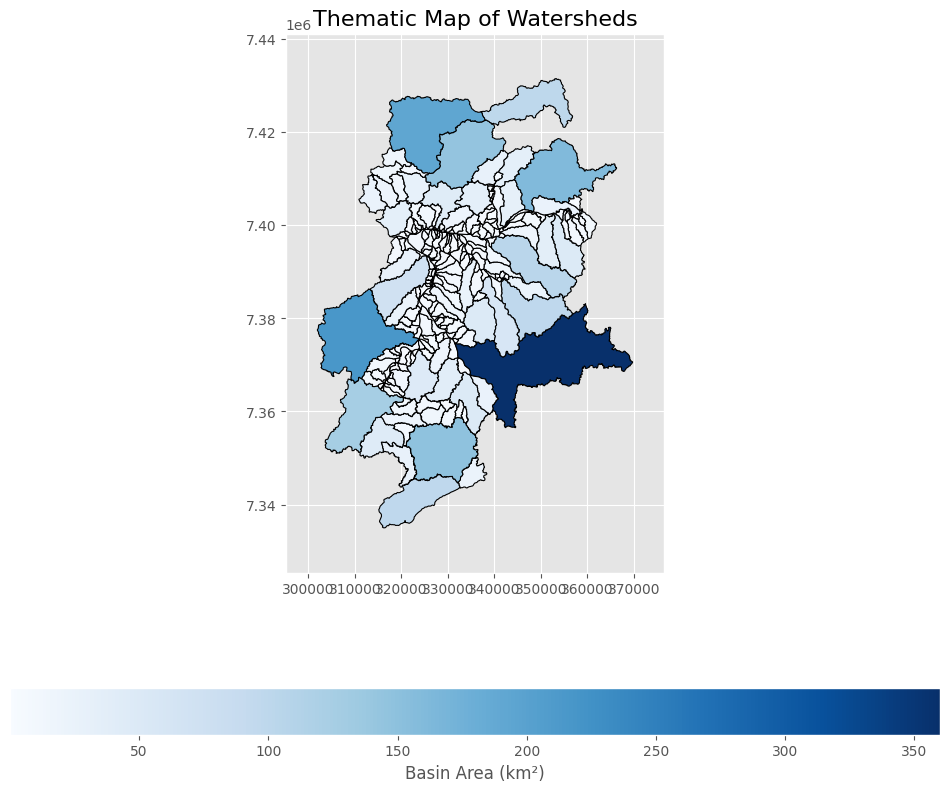

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx  # To add a base map

# Load the shapefile
gdf_bacia = gpd.read_file(caminho)

# Ensure the CRS is correctly set
#if gdf_bacia.crs is None:
#    gdf_bacia = gdf_bacia.set_crs(epsg=31983)
#elif gdf_bacia.crs.to_epsg() != 31983:
#    gdf_bacia = gdf_bacia.to_crs(epsg=31983)

# Convert to the desired CRS
#if gdf_bacia.crs.to_epsg() != my_crs.to_epsg():
#    gdf_bacia = gdf_bacia.to_crs(my_crs)

#print(f'The coordinate system used is {gdf_bacia.crs}')

# Create a thematic variable (example: coloring by basin area)
gdf_bacia["area_km2"] = gdf_bacia.geometry.area / 10**6  # Converting to km²

# Create the thematic map
fig, ax = plt.subplots(figsize=(12, 10))  # Increased figure size for better visibility
gdf_bacia.plot(column="area_km2", cmap="Blues", linewidth=0.8, edgecolor="black", 
               legend=True, legend_kwds={"label": "Basin Area (km²)", "orientation": "horizontal"}, ax=ax)

# Add a title
ax.set_title("Thematic Map of Watersheds", fontsize=16)

# Adjust the map extent (expanding it by 10%)
buffer = 0.1  # 10% buffer
minx, miny, maxx, maxy = gdf_bacia.total_bounds
ax.set_xlim(minx - buffer * (maxx - minx), maxx + buffer * (maxx - minx))
ax.set_ylim(miny - buffer * (maxy - miny), maxy + buffer * (maxy - miny))

# Add a high-resolution background map
ctx.add_basemap(ax, crs=gdf_bacia.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)

# Remove axes
ax.set_axis_off()

# Display the map
plt.show()


In [6]:
# Verifica os nomes das bacias presentes no arquivo
bacias_unicas = gdf_bacia['BACIA_NOME'].unique()
#print(bacias_unicas)

# Bacia desejada
bacia = 'Aricanduva'

# Filtrar as linhas que contêm a palavra procurada
linhas_contendo_bacia = filter(lambda linha: bacia in linha, bacias_unicas)

# Converter o resultado de volta para uma lista, se necessário
linhas_contendo_bacia = list(linhas_contendo_bacia)

# Exibir as linhas encontradas

for linha in linhas_contendo_bacia:
    print(linha)

Área de Contribuição Direta de Escoamento Difuso - Aricanduva/Tatuapé
Rio Aricanduva
Área de Contribuição Direta de Escoamento Difuso - Tiquatira/Aricanduva


EPSG:4326


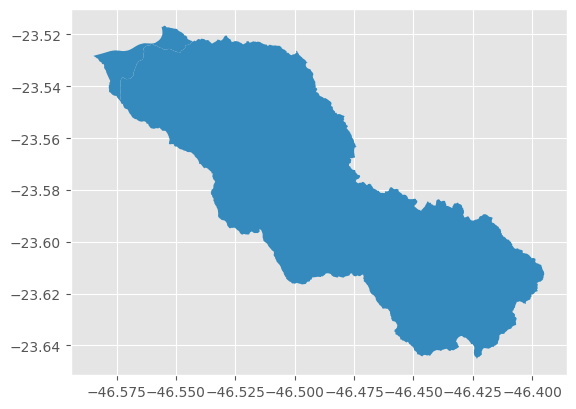

In [7]:
# Filtrando para a bacia do Aricanduva
gdf_Aricanduva = gdf_bacia[gdf_bacia['BACIA_NOME'].isin(linhas_contendo_bacia)]
gdf_Aricanduva.plot()
print(gdf_Aricanduva.crs)

In [37]:
### Fazer o download da rede viária correspondente a bacia
# Encontre os limites máximos e mínimos das coordenadas do GeoDataFrame
min_x, min_y, max_x, max_y = gdf_Aricanduva.total_bounds

# Certifique-se de que o CRS do seu GeoDataFrame está definido corretamente
#my_crs = gdf_Aricanduva.crs

# Crie um polígono representando a caixa delimitadora
bounding_box_bacia = box(min_x, min_y, max_x, max_y)

# Crie um novo GeoDataFrame com o polígono da caixa delimitadora
bounding_box_bacia_gdf = gpd.GeoDataFrame(geometry=[bounding_box_bacia], crs=my_crs)

bounding_box_bacia_gdf.to_file('bounding_box_bacia.json', driver="GeoJSON")

In [7]:
# Obter o grafo da rede de ruas aplicando o filtro personalizado
# Detalhes em https://wiki.openstreetmap.org/wiki/Highway:International_equivalence
cf = '["highway"!~"residential|busway|unclassified|living_street"]'

try:
    G_baseline = ox.graph_from_polygon(bounding_box_bacia, network_type='drive', custom_filter=cf)
    print("Grafo obtido com sucesso!")
    ox.save_graphml(G_baseline, filepath='network_baseline.graphml')
except:
    print(f"Erro ao obter o grafo!")

In [27]:
def remover_atributos(lista, atributos_para_remover):
    """
    Remove um atributo específico de uma lista e formata o resultado como uma string.

    Args:
    - lista: A lista de elementos.
    - atributo_para_remover: O atributo que deseja remover da lista.

    Returns:
    - Uma string formatada no formato: '['highway'˜'Atributo1|Atributo2|etc']'
      contendo todos os elementos da lista original, exceto o atributo especificado.
    """
    lista_sem_atributo = [item for item in lista if item not in atributos_para_remover]
    # Converter todos os itens para string
    lista_sem_atributo = [str(item) for item in lista_sem_atributo]
    atributos_formatados = '|'.join(lista_sem_atributo)
    return "['highway'~'{}']".format(atributos_formatados)

In [28]:
edges_explodido = edges_baseline.explode('highway')
valores_unicos = edges_explodido['highway'].unique()
print('\nOs valores únicos da tag highway são:\n{}',valores_unicos)

atributos_remover = ['residential', 'busway', 'unclassified', 'living_street','service', 'footway', 'pedestrian','construction', 'path', 'steps', 'track','platform','bus_stop','services','raceway','elevator']
print('\nOs valores removidos da tag highway são:\n{}',atributos_remover)

resultado_formatado = remover_atributos(valores_unicos, atributos_remover)
print('\nA lista com os valores removidaos é:\n{}',resultado_formatado)  # Saída: '['highway'˜'Atributo1|Atributo3']'

In [29]:
# Obter o grafo da rede de ruas aplicando o filtro personalizado
# Detalhes em https://wiki.openstreetmap.org/wiki/Highway:International_equivalence
cf = resultado_formatado

try:
    G_baseline = ox.graph_from_polygon(bounding_box_bacia, network_type='drive', custom_filter=cf)
    print("Grafo obtido com sucesso!")
    
except:
    print(f"Erro ao obter o grafo!")

In [30]:
ox.save_graphml(G_baseline, filepath='network_baseline.graphml')
G_baseline = ox.routing.add_edge_speeds(G_baseline, fallback=50)  # Adiciona a velocidade dos eixos (km/h) ao grafo como o atributo do eixo speed_kph
if verbose:
    # Este bloco será executado somente se verbose for True
    fig, ax = ox.plot_graph(G_baseline)
    plt.show()

In [ ]:
# Carregar o grafo de um arquivo GraphML
G_baseline = ox.load_graphml(filepath='network_baseline.graphml')

In [31]:
node_baseline, edges_baseline = ox.graph_to_gdfs(G_baseline)
if verbose:
    edges_baseline.explore(column="speed_kph",
                  tooltip="speed_kph",
                  popup=True,
                  tiles="CartoDB dark_matter",
                  cmap="inferno_r")
print("\nO comprimento total dessa rede é \033[1;31m{:,.2f} quilômetros\033[0m\n".format(edges_baseline['length'].sum() / 1000))

In [32]:
# Contar a quantidade de valores NaN na coluna speed_kph
nan_count = edges_baseline['speed_kph'].isna().sum()
print(f'Quantidade de valores NaN em speed_kph: {nan_count}')

# Verificação final das velocidades adicionadas
velocidades_produzidas = edges_baseline['speed_kph'].unique()
print(f'\n São {len(velocidades_produzidas)} valores de velocidade, representados abaixo: \n {velocidades_produzidas}')
# Substituir valores de speed_kph acima de 35
edges_baseline.loc[(edges_baseline['speed_kph'] > 35) & (edges_baseline['speed_kph'] < 45), 'speed_kph'] = 40
edges_baseline.loc[(edges_baseline['speed_kph'] > 45) & (edges_baseline['speed_kph'] < 55), 'speed_kph'] = 50

velocidades_produzidas2 = edges_baseline['speed_kph'].unique()
print(f'\n Atualizamos para {len(velocidades_produzidas2)} valores de velocidade, representados abaixo: \n {velocidades_produzidas2}')

In [33]:
edges_baseline.explore(
    column="highway",  # make choropleth based on "BoroName" column
    tooltip="highway",  # show "BoroName" value in tooltip (on hover)
    popup=True,  # show all values in popup (on click)
    tiles="CartoDB positron",  # use "CartoDB positron" tiles
    cmap="Set1",  # use "Set1" matplotlib colormap
)

In [34]:
# Atualizar o grafo com os novos valores
for u, v, key, data in G_baseline.edges(keys=True, data=True):
    if (u, v, key) in edges_baseline.index:
        data['speed_kph'] = edges_baseline.at[(u, v, key), 'speed_kph']

In [35]:
# Salvar o grafo atualizado
ox.save_graphml(G_baseline, filepath='network_baseline_vel_updated.graphml')